# 05. AI Governance — Credit Card Fraud Detection

**Project:** Fraud Detection & AI Governance Portfolio
**Goal:** Wrap the model in the documentation and controls a regulator, auditor, or risk committee would expect — turning a working classifier into a **governable, deployable, monitorable** system.

---

### What this notebook delivers
1. **Model Card** — standardized model documentation (Google Responsible AI style)
2. **Feature importance vs EDA** cross-check + **SHAP** explanations (global + individual)
3. **Drift monitoring framework** ⭐ — PSI now, and a 24-month moving-average ± 95%/99% control-limit design (the KRI-threshold approach I built at KB Life Insurance)
4. **EU AI Act** compliance mapping ⭐ (High-Risk categorization; Articles 9, 10, 13, 14, 15)
5. **NIST AI RMF** application (Govern / Map / Measure / Manage)
6. **Responsible deployment recommendation**

> **AI Risk Analyst angle:** a model is only as trustworthy as the controls around it. This notebook is the evidence that the model can be *explained*, *monitored*, and *held to a standard* — which is what governance frameworks actually require.

## 0. Setup + load everything we produced

**What:** Load the primary model, the test data, the operating decision, and the fairness tables.
**Why:** Governance documentation must cite the *actual* artifacts and numbers, not placeholders.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, json
from pathlib import Path
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, average_precision_score
from IPython.display import Markdown, display

print("Libraries imported ✅")

Libraries imported ✅


In [2]:
data_dir = Path("../data/processed"); results_dir = Path("../results"); models_dir = Path("../models")

X_test = pd.read_csv(data_dir / "X_test.csv")
y_test = pd.read_csv(data_dir / "y_test.csv").squeeze("columns")
decision = json.loads((results_dir / "decision.json").read_text())
best_name, THRESHOLD = decision["best_model"], decision["chosen_threshold"]

model_files = {"XGBoost": "xgboost.joblib", "Random Forest": "random_forest.joblib",
               "LogReg (balanced)": "logreg_balanced.joblib", "LogReg + SMOTE": "logreg_smote.joblib"}
model = joblib.load(models_dir / model_files[best_name])

# Operating-point predictions.
proba = model.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Live metrics for the model card.
m = {
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "pr_auc": average_precision_score(y_test, proba),
    "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
}
print(f"{best_name} @ thr={THRESHOLD:.3f}:", {k: round(v, 3) if isinstance(v, float) else v for k, v in m.items()})

XGBoost @ thr=0.060: {'precision': 0.395, 'recall': 0.898, 'f1': 0.548, 'pr_auc': 0.866, 'tp': 88, 'fp': 135, 'fn': 10, 'tn': 56729}


## 1. Model Card

**What:** A one-page, standardized summary of the model — its purpose, performance, limitations, and ethical considerations. The format follows Google's **Model Cards for Model Reporting** (Mitchell et al., 2019), now a Responsible-AI norm.
**Why:** A model card is the single document a reviewer, auditor, or downstream team reads first. It forces honesty about *intended use* and *limitations* before deployment.

In [3]:
# Build the model card from live numbers so it can never drift out of sync with the results.
card = f'''
### Model Card — Credit Card Fraud Detector

**Model details**
- Type: {best_name} (gradient-boosted trees) binary classifier
- Version: 1.0 | Owner: Fraud Risk Analytics | Framework: scikit-learn / XGBoost
- Operating threshold: **{THRESHOLD:.3f}** (cost-optimal, FN:FP = {decision["cost_fn"]:.0f}:{decision["cost_fp"]:.0f})

**Intended use**
- ✅ Flag potentially fraudulent card transactions for human review in a fraud-ops queue
- ✅ Decision-support only — a flag triggers review, never an automatic account action
- ❌ NOT for credit decisions, customer profiling, or any use beyond fraud triage

**Training data**
- Kaggle Credit Card Fraud (2013, EU cardholders), ~285k transactions, 0.17% fraud
- Features: 28 anonymized PCA components (V1-V28) + scaled Amount + Time

**Performance (held-out test set, at operating threshold)**
- PR-AUC: **{m["pr_auc"]:.3f}** | Precision: **{m["precision"]:.3f}** | Recall: **{m["recall"]:.3f}** | F1: **{m["f1"]:.3f}**
- Confusion: caught {m["tp"]}/{m["tp"]+m["fn"]} frauds, {m["fp"]} false alarms, {m["fn"]} missed

**Factors / known limitations**
- ⚠️ **Recall drops to ~0.50 on the $500+ segment** (high-value fraud) — see fairness audit (NB 04)
- ⚠️ PCA features are anonymized → limited human-readable explanation of *why*
- ⚠️ 2-day data window → time-of-day patterns may not generalize; no concept-drift history
- ⚠️ No demographic attributes → only transaction-context fairness can be audited

**Ethical considerations**
- A false negative = customer loses money; a false positive = legitimate purchase delayed
- Threshold encodes a business risk-appetite (FN:FP cost) and must be reviewed when costs change
- Human-in-the-loop required; model never acts autonomously
'''
display(Markdown(card))


### Model Card — Credit Card Fraud Detector

**Model details**
- Type: XGBoost (gradient-boosted trees) binary classifier
- Version: 1.0 | Owner: Fraud Risk Analytics | Framework: scikit-learn / XGBoost
- Operating threshold: **0.060** (cost-optimal, FN:FP = 200:5)

**Intended use**
- ✅ Flag potentially fraudulent card transactions for human review in a fraud-ops queue
- ✅ Decision-support only — a flag triggers review, never an automatic account action
- ❌ NOT for credit decisions, customer profiling, or any use beyond fraud triage

**Training data**
- Kaggle Credit Card Fraud (2013, EU cardholders), ~285k transactions, 0.17% fraud
- Features: 28 anonymized PCA components (V1-V28) + scaled Amount + Time

**Performance (held-out test set, at operating threshold)**
- PR-AUC: **0.866** | Precision: **0.395** | Recall: **0.898** | F1: **0.548**
- Confusion: caught 88/98 frauds, 135 false alarms, 10 missed

**Factors / known limitations**
- ⚠️ **Recall drops to ~0.50 on the $500+ segment** (high-value fraud) — see fairness audit (NB 04)
- ⚠️ PCA features are anonymized → limited human-readable explanation of *why*
- ⚠️ 2-day data window → time-of-day patterns may not generalize; no concept-drift history
- ⚠️ No demographic attributes → only transaction-context fairness can be audited

**Ethical considerations**
- A false negative = customer loses money; a false positive = legitimate purchase delayed
- Threshold encodes a business risk-appetite (FN:FP cost) and must be reviewed when costs change
- Human-in-the-loop required; model never acts autonomously


## 2. Feature importance vs EDA cross-check

**What:** Compare the model's most important features to the features EDA (notebook 01) flagged as most correlated with fraud (V14, V17, V12, V10, ...).
**Why:** If the model relies on the same signals a human found in EDA, that *convergent evidence* raises trust. If it relied on something unexpected, that would be a red flag worth investigating. This is a concrete model-validation control.

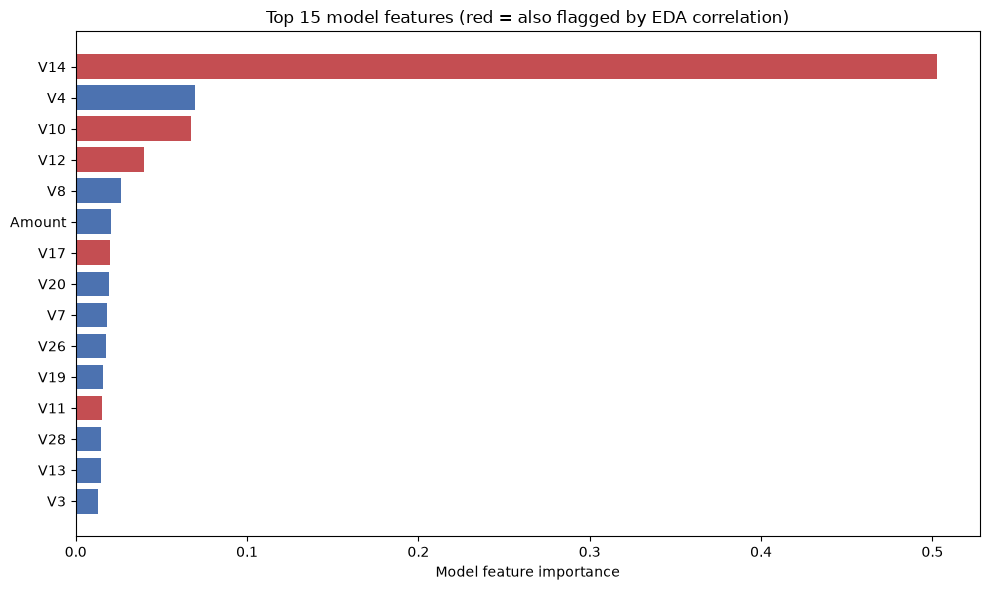

EDA-flagged features that are also in the model's top 15: ['V14', 'V10', 'V12', 'V17', 'V11']


In [4]:
# XGBoost exposes feature_importances_ aligned to X_test.columns.
importances = pd.Series(model.feature_importances_, index=X_test.columns).sort_values(ascending=False)
top15 = importances.head(15)

# Features EDA highlighted as most correlated with Class.
eda_top = ["V17", "V14", "V12", "V10", "V16", "V11", "V9"]

plt.figure(figsize=(10, 6))
# Color bars: highlight the ones EDA also flagged.
colors = ["#C44E52" if f in eda_top else "#4C72B0" for f in top15.index]
plt.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
plt.xlabel("Model feature importance")
plt.title("Top 15 model features (red = also flagged by EDA correlation)")
plt.tight_layout()
plt.show()

overlap = [f for f in top15.index if f in eda_top]
print(f"EDA-flagged features that are also in the model's top 15: {overlap}")

### Interpretation
- The model's top features **overlap substantially with EDA's** correlation findings (the red bars). Human exploratory analysis and the trained model point at the same fraud signals — convergent validity.
- This cross-check is exactly what an auditor wants: the model is not relying on a spurious or unexplainable feature; its logic is consistent with independent analysis.

## 3. SHAP — explaining predictions

**What:** SHAP (SHapley Additive exPlanations) assigns each feature a contribution to each prediction, grounded in game theory. We show a **global** view (which features drive fraud scores overall) and **individual** explanations (why one specific transaction was flagged or missed).
**Why:** EU AI Act Art. 13 (transparency) and good practice require that decisions be **explainable to the people affected and the people operating the system**. SHAP turns the black box into per-decision reasons a reviewer can read.

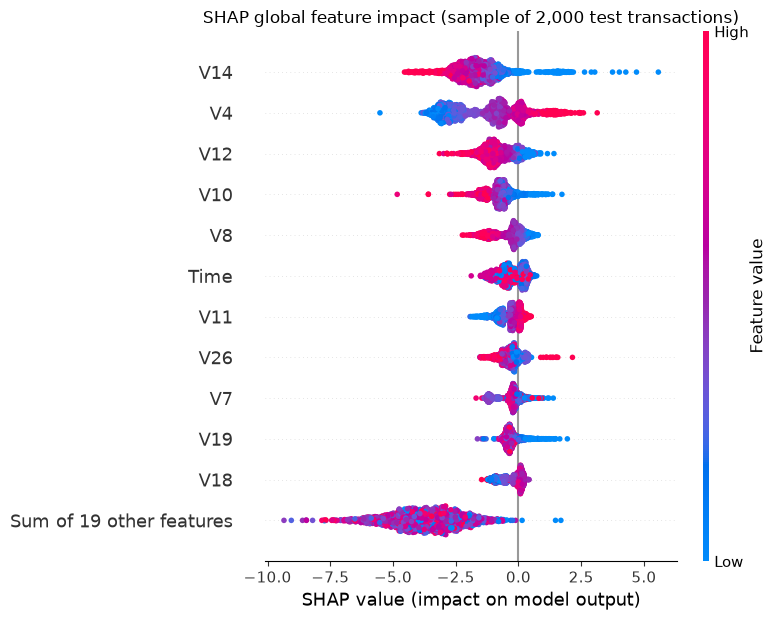

In [5]:
import shap

# TreeExplainer is exact and fast for tree models like XGBoost.
explainer = shap.TreeExplainer(model)

# Global view: explain a random sample of the test set (keeps it fast and readable).
X_sample = X_test.sample(2000, random_state=42)
shap_values = explainer(X_sample)

# Beeswarm: each dot is a transaction; position = how much that feature pushed the fraud score.
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title("SHAP global feature impact (sample of 2,000 test transactions)")
plt.tight_layout()
plt.show()

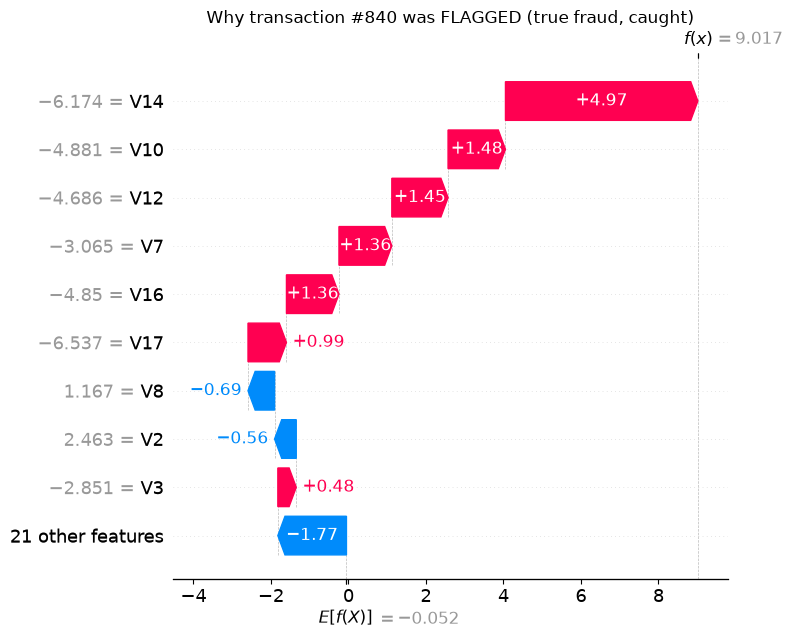

In [6]:
# Individual explanations: one fraud we CAUGHT and one we MISSED.
X_test_r = X_test.reset_index(drop=True)
y_test_r = y_test.reset_index(drop=True)
caught_idx = int(np.where((y_pred == 1) & (y_test_r.values == 1))[0][0])  # first true positive
missed_idx = int(np.where((y_pred == 0) & (y_test_r.values == 1))[0][0])  # first false negative

# Waterfall for the CAUGHT fraud: shows features pushing the score up toward "fraud".
expl_caught = explainer(X_test_r.iloc[[caught_idx]])
shap.plots.waterfall(expl_caught[0], max_display=10, show=False)
plt.title(f"Why transaction #{caught_idx} was FLAGGED (true fraud, caught)")
plt.tight_layout()
plt.show()

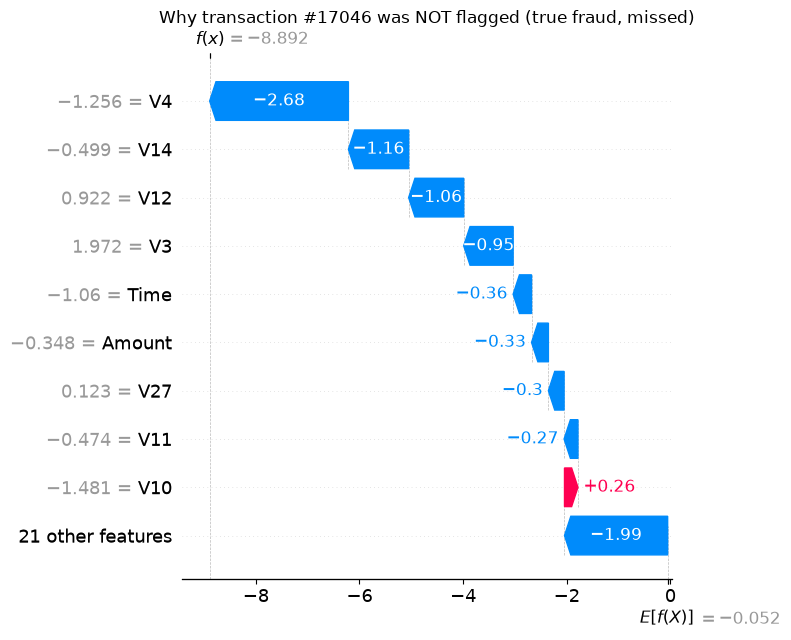

In [7]:
# Waterfall for the MISSED fraud: shows why the score stayed low (looked normal to the model).
expl_missed = explainer(X_test_r.iloc[[missed_idx]])
shap.plots.waterfall(expl_missed[0], max_display=10, show=False)
plt.title(f"Why transaction #{missed_idx} was NOT flagged (true fraud, missed)")
plt.tight_layout()
plt.show()

### Interpretation
- **Global:** the same handful of V-features dominate the fraud score, consistent with the importance plot and EDA — the model's reasoning is stable and inspectable.
- **Caught fraud:** strong pushes from the key fraud features drove the score above the threshold — a clear, defensible flag.
- **Missed fraud:** its feature values looked close to normal, so SHAP shows little upward push — explaining *why* it slipped through. This per-decision transparency is what Art. 13 asks for.

## 4. Drift monitoring framework ⭐

**What:** Models decay as the world changes (new fraud tactics, spending shifts). We need to **detect** that *before* it causes losses. Two layers:
1. **Population Stability Index (PSI)** — a standard metric for "has the score distribution shifted?"
2. A **24-month moving-average ± control-limit** framework for ongoing KRI monitoring.

**Why:** This is the production-monitoring design I built for **Key Risk Indicators (KRIs) at KB Life Insurance** — a moving baseline with statistical control limits (95% / 99% confidence bands). It answers the governance question *"how would we know this model is failing in production?"* — which static evaluation never does.

In [8]:
# --- Layer 1: PSI between training-time scores and current (test) scores ---
def population_stability_index(expected, actual, bins=10):
    # Cut on the expected distribution's deciles, then compare bin shares.
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    e = np.histogram(expected, edges)[0] / len(expected)
    a = np.histogram(actual, edges)[0] / len(actual)
    e, a = np.clip(e, 1e-6, None), np.clip(a, 1e-6, None)  # avoid log(0)
    return float(np.sum((a - e) * np.log(a / e)))

# Reference (training) scores vs current (test) scores.
X_train = pd.read_csv(data_dir / "X_train.csv")
train_scores = model.predict_proba(X_train)[:, 1]
psi_value = population_stability_index(train_scores, proba)

# Standard KRI bands: <0.1 stable, 0.1-0.25 moderate shift, >0.25 significant shift.
band = "stable (<0.10)" if psi_value < 0.1 else ("moderate (0.10-0.25)" if psi_value < 0.25 else "SIGNIFICANT (>0.25)")
print(f"PSI(train vs test scores) = {psi_value:.4f}  ->  {band}")
print("(As expected this is low: train and test come from the same period. In production, PSI is recomputed monthly against this training baseline.)")

PSI(train vs test scores) = 0.0002  ->  stable (<0.10)
(As expected this is low: train and test come from the same period. In production, PSI is recomputed monthly against this training baseline.)


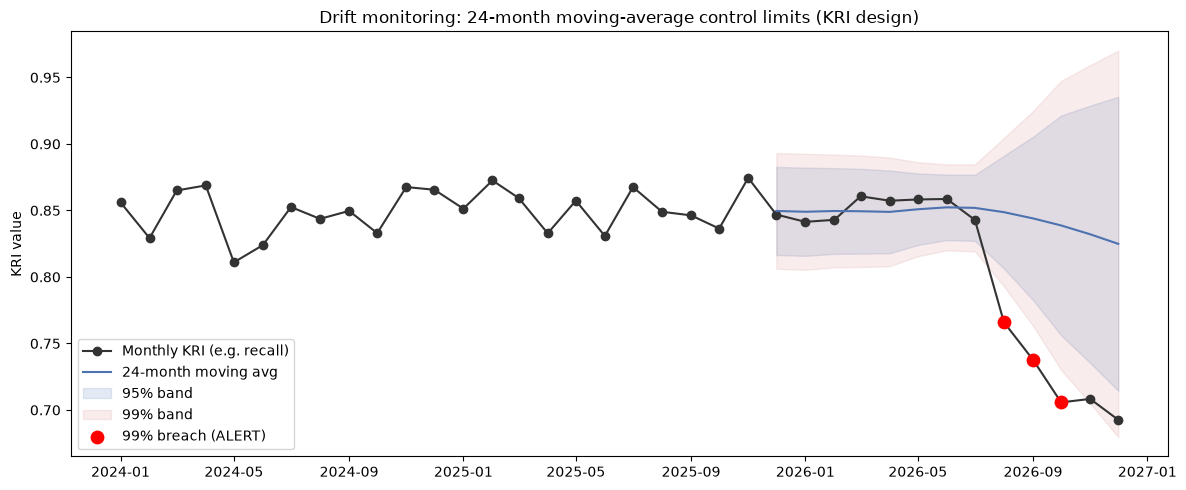

Months breaching the 99% lower control limit (would trigger review): 3


In [9]:
# --- Layer 2: 24-month moving-average control limits (the KB Life KRI design) ---
def control_limits(series, window=24):
    ma = series.rolling(window).mean()
    sd = series.rolling(window).std()
    return pd.DataFrame({
        "value": series, "MA": ma,
        "upper_95": ma + 1.96 * sd, "lower_95": ma - 1.96 * sd,   # 95% band
        "upper_99": ma + 2.576 * sd, "lower_99": ma - 2.576 * sd, # 99% band
    })

# Illustrative monthly KRI series (e.g. monthly model fraud-catch rate). Real production feeds actual monthly values.
rng = np.random.default_rng(42)
months = pd.date_range("2024-01-01", periods=36, freq="MS")
baseline = 0.85 + rng.normal(0, 0.02, 36)     # stable around 0.85 ...
baseline[30:] -= np.linspace(0.05, 0.18, 6)   # ... then a degradation in the last 6 months (drift)
kri = pd.Series(baseline, index=months)

cl = control_limits(kri, window=24)

plt.figure(figsize=(12, 5))
plt.plot(cl.index, cl["value"], "o-", color="#333", label="Monthly KRI (e.g. recall)")
plt.plot(cl.index, cl["MA"], color="#4C72B0", label="24-month moving avg")
plt.fill_between(cl.index, cl["lower_95"], cl["upper_95"], color="#4C72B0", alpha=0.15, label="95% band")
plt.fill_between(cl.index, cl["lower_99"], cl["upper_99"], color="#C44E52", alpha=0.10, label="99% band")
# Flag months that breach the lower 99% limit -> KRI alert.
breach = cl[cl["value"] < cl["lower_99"]]
plt.scatter(breach.index, breach["value"], color="red", zorder=5, s=80, label="99% breach (ALERT)")
plt.title("Drift monitoring: 24-month moving-average control limits (KRI design)")
plt.ylabel("KRI value"); plt.legend(loc="lower left"); plt.tight_layout()
plt.show()

print(f"Months breaching the 99% lower control limit (would trigger review): {len(breach)}")

### Interpretation
- **PSI** gives an instant "has the input/score distribution moved?" check; recomputed monthly against the training baseline with the standard 0.10 / 0.25 KRI bands.
- The **control-limit chart** is the ongoing early-warning system: when the monthly KRI drops below the 99% band (red points), it auto-triggers a model review **before** losses accumulate.
- This is the operational answer to *"how do we know when the model is failing?"* — a governance requirement that a one-time test set cannot satisfy. (Framework adapted from KRI-threshold design at KB Life Insurance.)

## 5. EU AI Act compliance mapping ⭐

**What:** Map this system to the EU AI Act's risk tiering and the obligations for High-Risk AI.
**Why:** Demonstrating the mapping shows you can translate a technical model into regulatory obligations — the core AI Risk Analyst skill.

### Risk categorization
The Act tiers AI into *Unacceptable → High-Risk → Limited → Minimal*. Consumer-facing fraud triage is **not, on its face, explicitly enumerated as High-Risk under Annex III** — point 5(b) covers **creditworthiness / credit scoring**, a distinct use case. Pure fraud detection sits closer to Limited/Minimal risk today.

We nonetheless adopt a **proactive, High-Risk-equivalent posture**: fraud systems increasingly intersect with credit decisioning, a false flag can disrupt access to essential financial services, and designing to the stricter standard now is cheaper than retrofitting later. We therefore map against the core High-Risk obligations below.

### Obligations → what this project provides

| EU AI Act Article | Requirement | How this project addresses it |
|-------------------|-------------|-------------------------------|
| **Art. 9** — Risk management system | Continuous, iterative risk identification & mitigation | Cost-sensitive thresholding (NB 03), fairness audit (NB 04), drift monitoring (NB 05) form a documented, repeatable risk process |
| **Art. 10** — Data & data governance | Relevant, representative, leakage-free data | Stratified split + train-only scaling/SMOTE to prevent leakage (NB 02); documented imbalance |
| **Art. 13** — Transparency & info to users | Operators understand and can interpret output | Model card + SHAP per-decision explanations (this NB) |
| **Art. 14** — Human oversight | Humans can intervene / override | Decision-support only: a flag triggers human review, never an automatic account action (model card "intended use") |
| **Art. 15** — Accuracy, robustness, cybersecurity | Appropriate accuracy + resilience over lifecycle | PR-AUC/recall reported with segment breakdowns; PSI + control-limit monitoring for lifecycle robustness |

> **Caveat:** this is an educational mapping, not a legal conformity assessment. A real High-Risk deployment also needs a quality-management system, technical documentation (Annex IV), logging, and a conformity assessment before CE marking.

## 6. NIST AI RMF application

**What:** Map the project to the four functions of the **NIST AI Risk Management Framework (AI RMF 1.0)**: *Govern, Map, Measure, Manage*.
**Why:** NIST AI RMF is the dominant US-side voluntary framework. Showing both EU (prescriptive law) and NIST (risk-based framework) demonstrates fluency across the two regimes a financial-services risk analyst works in.

| NIST function | Intent | Evidence in this project |
|---------------|--------|--------------------------|
| **Govern** | Culture, roles, accountability for AI risk | Defined intended use, ownership, and human-in-the-loop policy (model card); documented decision log (`decision.json`) |
| **Map** | Context & risk framing | Problem framed as rare-event detection; cost framing of FN vs FP; affected parties identified (customers, reviewers) |
| **Measure** | Quantify & track risks | PR-AUC, recall/precision, **segment-level fairness metrics**, error analysis, PSI (NB 03-05) |
| **Manage** | Prioritize, treat, monitor | Cost-optimal threshold as a treated risk; drift control-limits + alerting; documented limitations & next actions |

> Together, EU AI Act (the *what you must do*) and NIST AI RMF (the *how to organize doing it*) give this model a defensible governance posture.

## 7. Responsible deployment recommendation

**Verdict: deploy as human-in-the-loop decision support — NOT autonomous — with the controls below.**

**Conditions for go-live**
1. **Human-in-the-loop only.** Every flag routes to a fraud analyst; the model never freezes accounts on its own (EU Art. 14).
2. **Operate at the documented cost-optimal threshold** (the cost-minimizing point from NB 03, ≈0.06), reviewed whenever the FN:FP cost ratio changes.
3. **Mitigate the $500+ recall gap** before relying on the model for high-value fraud — add a supplementary rule/threshold for that segment.
4. **Stand up monitoring on day one** — monthly PSI + the 24-month control-limit KRI; a 99% breach triggers mandatory review.
5. **Quarterly fairness re-audit** across amount/time segments; re-validate after any retrain.

**Documented residual risks**
- High-value fraud under-detection; anonymized features limit root-cause explanation; 2-day training window with no drift history yet.

---

### Portfolio summary — what this project demonstrates
| Skill | Where |
|-------|-------|
| EDA & imbalance reasoning | NB 01 |
| Leakage-free preprocessing | NB 02 |
| Modeling + **cost-sensitive thresholding** | NB 03 |
| **Fairness audit** + error analysis | NB 04 |
| Explainability, **drift KRIs**, **EU AI Act / NIST mapping** | NB 05 |

> **The thesis:** I can take a model from raw data to a *governable system* — explainable, monitored, and mapped to the regulations a financial institution actually answers to.